In [2]:
import os 
import random

import h5py
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the data from the json files

heatmap_dir = '../heatmap_norm'
json_files = [f for f in os.listdir(heatmap_dir) if f.endswith('.json')]

# load as numpy arrays
data = []
for f in json_files:
    with open(os.path.join(heatmap_dir, f), 'r') as file:
        data.append(json.load(file))

threshold = 200
threshold_count = 0

data = np.array(data)
filtered_data = data[np.sum(data > 0, axis=(1, 2)) > threshold]

print(f'Number of heatmaps: {len(data)}')
print(f'Number of heatmaps with more than {threshold} points: {len(filtered_data)}')

Number of heatmaps: 45
Number of heatmaps with more than 200 points: 25


In [4]:
# drop_indices = [4, 12, 20, 21, 23]
# for i in drop_indices:
#     filtered_data[i] = None
#     filtered_data[i] = None

# filtered_data = [x for x in filtered_data if x is not None]

# for i in drop_indices:
#     filtered_data[i] = None
#     filtered_data[i] = None

# filtered_data = [x for x in filtered_data if x is not None]

print(f'Number of heatmaps after dropping some: {len(filtered_data)}')

Number of heatmaps after dropping some: 25


Number of heatmaps after filtering: 25


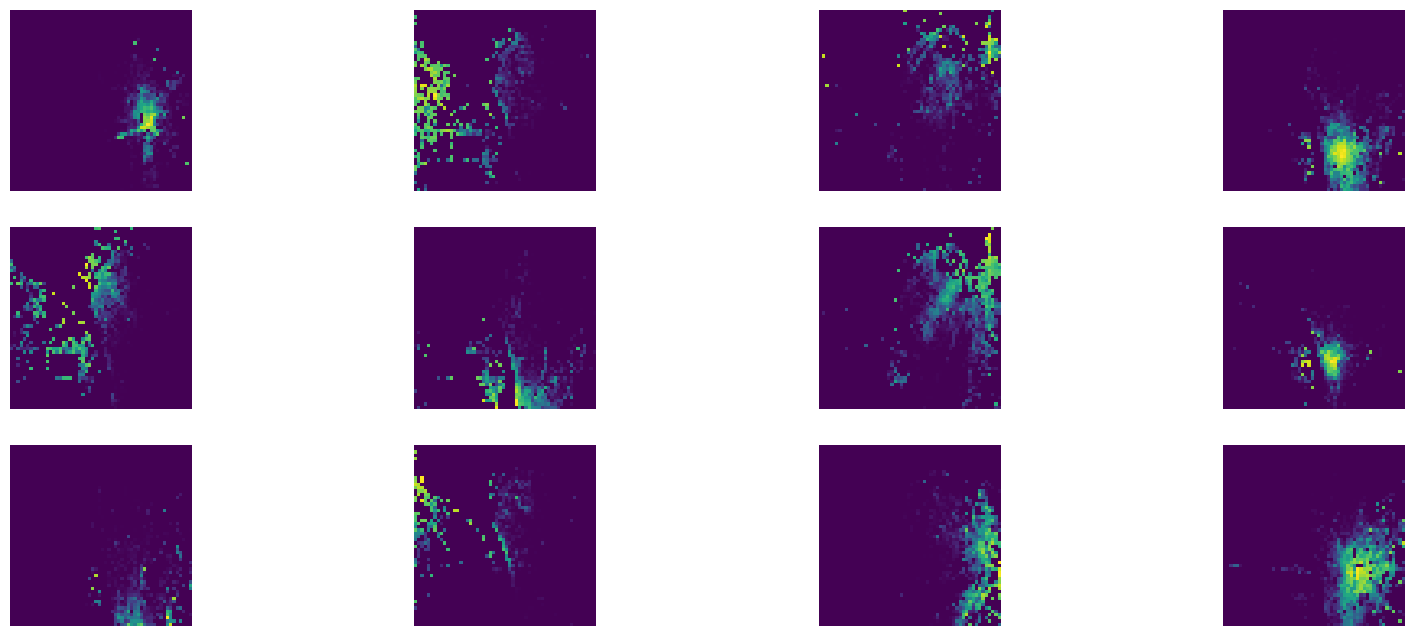

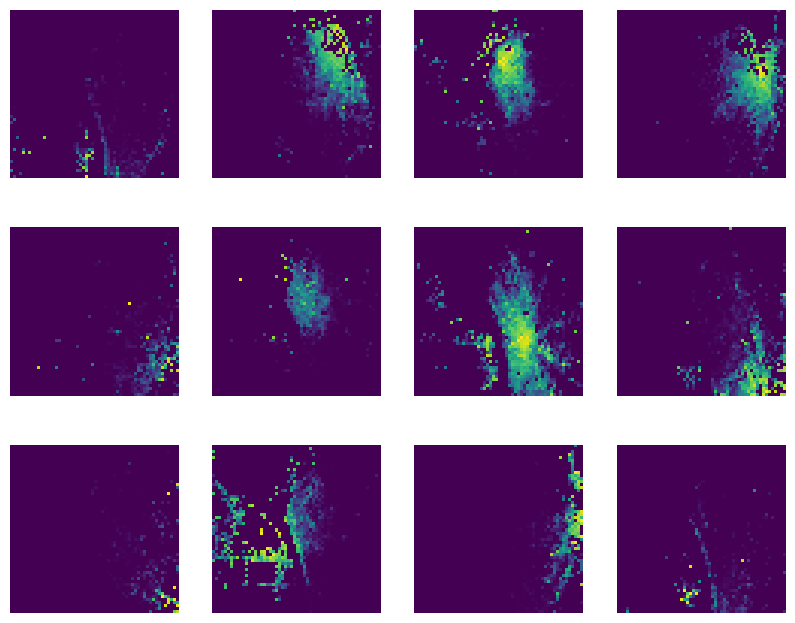

Number of heatmaps after filtering: 25
Number of centers after filtering: 20


In [24]:
# Manual work, I am so tired
print(f'Number of heatmaps after filtering: {len(filtered_data)}')

drop_indices = [4, 12, 20, 21, 23]
center = [(35,42),(28,10),(10,45),(43,36),
          (52,28),(12,48),(40,32),(45,40),(20,15),
          (39,51),(39,42),(18,40),(20,32),
          (25,46),(45,45),(22,30),(38,35),(43,45),
          (28,50),(50,48),] # manually selected centers (y, x)/ (row, col) / (axis 0, axis 1)
# gd:0, 3, 7, 11, 13, 14, 15, 17, 18, 19, 22
# ok: 1, 6, 8, 10, 21, 23, 24
# bad: 2, 4, 5, 9, 16
# delete: 12, 20

# 25 heatmaps
fig, ax = plt.subplots(3, 4, figsize=(20, 8))
for i, d in enumerate(filtered_data[:12]):
    # plot the heatmap
    row = i // 4
    col = i % 4
    ax[row, col].imshow(d, cmap='viridis')
    ax[row, col].axis('off')
    # ax[row, col].scatter(center[i][1], center[i][0], c='b', marker='x')
plt.show()

fig, ax = plt.subplots(3, 4, figsize=(10, 8))
for i, d in enumerate(filtered_data[12:24]):
    # plot the heatmap
    row = i // 4
    col = i % 4
    ax[row, col].imshow(d, cmap='viridis')
    ax[row, col].axis('off')
    # ax[row, col].scatter(center[i][1], center[i][0], c='b', marker='x')
plt.show()

print(f'Number of heatmaps after filtering: {len(filtered_data)}')
print(f'Number of centers after filtering: {len(center)}')

In [37]:
import numpy as np

def shift_2d_replace(data, dx, dy, constant=False):
    """
    Shifts the array in two dimensions while setting rolled values to constant
    :param data: The 2d numpy array to be shifted
    :param dx: The shift in x
    :param dy: The shift in y
    :param constant: The constant to replace rolled values with
    :return: The shifted array with "constant" where roll occurs
    """
    shifted_data = np.roll(data, dx, axis=1)
    if dx < 0:
        shifted_data[:, dx:] = constant
    elif dx > 0:
        shifted_data[:, 0:dx] = constant

    shifted_data = np.roll(shifted_data, dy, axis=0)
    if dy < 0:
        shifted_data[dy:, :] = constant
    elif dy > 0:
        shifted_data[0:dy, :] = constant
    return shifted_data

# test_heatmap = filtered_data[0]
# center_test = center[0]

# target_shift_target = ((32,12), (12,32)) # y, x
# for shift_target in target_shift_target:
#     dy, dx = (shift_target[0] - center_test[0], shift_target[1] - center_test[1])
#     shifted_heatmap = shift_2d_replace(test_heatmap, dx, dy)
#     plt.figure()
#     plt.imshow(shifted_heatmap, cmap='viridis')
#     plt.scatter(shift_target[1], shift_target[0], c='r', s=20)
#     plt.show()


In [ ]:
shift_x = np.arange(16, 40, 4)
shift_y = np.arange(16, 40, 4)
shift_xy = np.array([(y, x) for x in shift_x for y in shift_y])
shift_xy.shape

In [ ]:
np.hstack((np.arange(1, 21, 1), np.arange(21, 101, 5), np.arange(101, 901, 100))).shape

In [ ]:
# Process and save the data to a hdf5 file
import tqdm

# train_hdf5_file_path = os.path.join("../data", "train_heatmap_norm.h5") # training data
# test_hdf5_file_path = os.path.join("../data", "test_heatmap_norm.h5") # test data
train_hdf5_file_path = os.path.join("../data", "train_heatmap_norm_small.h5") # training data
test_hdf5_file_path = os.path.join("../data", "test_heatmap_norm_small.h5") # test data


# sample_sizes = np.arange(1, 101, 1)
sample_sizes = np.hstack((np.arange(1, 21, 1), np.arange(21, 101, 5), np.arange(101, 901, 100)))
sample_combinations = 4
heatmap_shape = (56, 56)

shift_x = np.arange(12, 44, 8)
shift_y = np.arange(12, 44, 8)
shift_xy = np.array([(x, y) for x in shift_x for y in shift_y])

train_filtered_data = filtered_data[:int(0.8*len(filtered_data))]
test_filtered_data = filtered_data[int(0.8*len(filtered_data)):]
print(f"Train data: {len(train_filtered_data)}")
print(f"Test data: {len(test_filtered_data)}")

def save_data_to_hdf5(hdf5_file_path, filtered_data, sample_sizes, sample_combinations, heatmap_shape, center, shift_xy):
    with h5py.File(hdf5_file_path, "w") as f:
        ground_truth_group = f.create_group("ground_truth")
        sampled_points_group = f.create_group("sampled_points")
        metadata_group = f.create_group("metadata")

        metadata_group.attrs["total_len"] = len(filtered_data) * (len(shift_xy) + 1) * sample_combinations * len(sample_sizes)
        metadata_group.attrs["num_ground_truth_heatmaps"] = len(filtered_data) * (len(shift_xy) + 1) # including the original heatmap
        metadata_group.attrs["num_heatmaps_combinations"] = sample_combinations * len(sample_sizes)
        metadata_group.attrs["heatmap_shape"] = heatmap_shape

        pbar = tqdm.tqdm(total=metadata_group.attrs["total_len"])

        for i, heatmap in enumerate(filtered_data):
            for shift_ldx in range(-1, len(shift_xy)): # -1 is the original heatmap
                count = 0
                heatmap_idx = i * (len(shift_xy) + 1) + shift_ldx
                if shift_ldx == -1:
                    shifted_heatmap = heatmap
                else:
                    dy, dx = (shift_xy[shift_ldx][0] - center[i][0], shift_xy[shift_ldx][1] - center[i][1])
                    shifted_heatmap = shift_2d_replace(heatmap, dx=dx, dy=dy)
                
                # check nan values, if yes raise error
                if np.isnan(shifted_heatmap).any():
                    raise ValueError("Nan values in the heatmap")
                non_zero_target_points = np.argwhere(shifted_heatmap > 0) # only the points with rssi values
                all_target_points = np.argwhere(shifted_heatmap >= 0) # all the points, excluding the points exceeding the heatmap size during shifting
                all_indices = np.arange(len(all_target_points))
                non_zero_indices = np.where((all_target_points[:, None] == non_zero_target_points).all(-1))[0]
                shifted_heatmap[shifted_heatmap < 0] = 0 # set the negative values to 0 after using it to build the target points
                ground_truth_group.create_dataset(f'{heatmap_idx + 1}', data=shifted_heatmap)

                for sample_size in sample_sizes:
                    for j in range(sample_combinations):
                        all_sample_size = sample_size // 2 # select 1/2 of the points from the whole heatmap
                        non_zero_sample_size = sample_size - all_sample_size # select 1/2 of the points from the points with rssi values
                        # remarks: becareful with sampling same points twice
                    
                        sampled_indices = np.random.choice(all_indices, all_sample_size, replace=False)
                        non_zero_indices_copy = np.setdiff1d(np.copy(non_zero_indices), sampled_indices)
                        non_zero_sample_size = min(non_zero_sample_size, len(non_zero_indices_copy)) # check if the sample size is greater than the available points
                        sampled_indices = np.concatenate((sampled_indices, np.random.choice(non_zero_indices_copy, non_zero_sample_size, replace=False)))
                        indices = tuple(all_target_points[sampled_indices].T)

                        shifted_heatmap_copy = np.zeros_like(shifted_heatmap)
                        sample_map = np.zeros_like(shifted_heatmap)

                        shifted_heatmap_copy[indices] = shifted_heatmap[indices]
                        sample_map[indices] = 1
                        sampled_points_group.create_dataset(f'data_{heatmap_idx + 1}_{count}', data=np.concatenate((shifted_heatmap_copy, sample_map)).reshape(2, heatmap_shape[0], heatmap_shape[1]))
                        count += 1
                        pbar.update(1)
        pbar.close()


save_data_to_hdf5(train_hdf5_file_path, train_filtered_data, sample_sizes, sample_combinations, heatmap_shape, center[:int(0.8*len(filtered_data))], shift_xy)
save_data_to_hdf5(test_hdf5_file_path, test_filtered_data, sample_sizes, sample_combinations, heatmap_shape, center[int(0.8*len(filtered_data)):], shift_xy)

In [ ]:
# heat_map = np.arange(9).reshape(3,3) + 1
# non_zero_target_points = np.array([[0,0],[1,1],[2,2]])
# all_target_points = np.array([[0,0],[0,1],[0,2],[1,0],[1,1],[1,2],[2,0],[2,1],[2,2]]) # given non_zero_target_points must be a subset of all_target_points

# all_indices = np.arange(len(all_target_points))
# non_zero_indices = np.where((all_target_points[:, None] == non_zero_target_points).all(-1))[0]

# print(all_indices)
# print(non_zero_indices)

# sample_size = 3
# all_sample_size = sample_size // 3
# non_zero_sample_size = sample_size - all_sample_size

# print(f"all_sample_size: {all_sample_size}")
# print(f"non_zero_sample_size: {non_zero_sample_size}\n")

# sampled_indices = np.random.choice(all_indices, all_sample_size, replace=False)
# print(f"sampled_indices: {sampled_indices}")
# non_zero_indices_copy = np.setdiff1d(np.copy(non_zero_indices), sampled_indices)
# print(f"non_zero_indices_copy: {non_zero_indices_copy}")
# sampled_indices = np.concatenate((sampled_indices, np.random.choice(non_zero_indices_copy, non_zero_sample_size, replace=False)))
# print(f"Final sampled_indices: {sampled_indices}")

# indices = tuple(all_target_points[sampled_indices].T)
# print(f"indices: {indices}")
# print(f"all_target_points[indices]: {heat_map[indices]}")


In [ ]:
import os

import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision.transforms import v2

# Print the structure of the hdf5 file
hdf5_file_path = os.path.join("../data", "train_heatmap_norm_small.h5")


transforms = v2.Compose([
    v2.RandomResizedCrop(size=(56, 56), antialias=True),
    v2.RandomRotation(degrees=15),
])


with h5py.File(hdf5_file_path, "r") as f:
    # print all metadata
    for key in f['metadata'].attrs.keys():
        print(key, f['metadata'].attrs[key])
        # print(f['sampled_points'].keys())

    # Plot a heatmap, sampled heatmap and sample map
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    heatmap_idx = 17 * 0 + 14
    num_samples = 175
    x, (c, context_mask) = f['ground_truth'][f'{heatmap_idx}'], f['sampled_points'][f'data_{heatmap_idx}_{num_samples}']
    x = torch.tensor(np.array(x))
    c = torch.tensor(np.array(c))
    context_mask = torch.tensor(np.array(context_mask))

    # combine x,c,context_mask to transform together
    combined = torch.cat((x.unsqueeze(0), c.unsqueeze(0), context_mask.unsqueeze(0)))


    ax[0].imshow(x.squeeze(0).numpy())
    ax[0].set_title('Ground truth')
    ax[1].imshow(c.squeeze(0).numpy())
    ax[1].set_title('Sampled heatmap')
    sample_map = context_mask.squeeze(0).numpy()
    ax[2].imshow(sample_map)
    ax[2].set_title(f'Sample map with {np.sum(sample_map)} points')
    plt.show()



In [ ]:
import torch
from torch.utils.data import Dataset

train_hdf5_file_path = os.path.join("../data", "train_heatmap_norm.h5") # training data
test_hdf5_file_path = os.path.join("../data", "test_heatmap_norm.h5") # test data

class LoRaHeatmapDatasetV1(Dataset):
    def __init__(self, h5_file_path):
        self.h5_file = h5py.File(h5_file_path, 'r')
        self.total_len = self.h5_file['metadata'].attrs['total_len']
        self.num_gt = self.h5_file['metadata'].attrs['num_ground_truth_heatmaps']
        self.num_conbinations = self.h5_file['metadata'].attrs['num_heatmaps_combinations']

    def __len__(self):
        return self.total_len
    
    def __getitem__(self, idx):
        gt_idx, heatmap_idx = divmod(idx, self.num_conbinations)
        key = f"data_{gt_idx}_{heatmap_idx}"
        data = torch.tensor(np.array(self.h5_file["sampled_points"][key]), dtype=torch.float32)
        gt = torch.tensor(np.array(self.h5_file['ground_truth'][f'{gt_idx}']), dtype=torch.float32)

        return gt, data[0], data[1]

# Create the dataset
dataset = LoRaHeatmapDatasetV1(test_hdf5_file_path)

data = dataset[950]
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(data[0])
ax[0].set_title('Ground truth')
ax[1].imshow(data[1])
ax[1].set_title('Sampled heatmap')
ax[2].imshow(data[2])
ax[2].set_title('Sample map')

for d in data:
    print(type(d), d.dtype, d.shape)
plt.show()

In [ ]:
import os
import sys

import torch

sys.path.append(f'{os.getcwd()}/../')
from app.context_unet import ContextUnetV2

model = ContextUnetV2(in_channels=1, n_feat=256)
# get number of model parameters
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())}")

# test the model
x = torch.randn(1, 1, 56, 56)
c = torch.randn(1, 1, 56, 56)
context_mask = torch.randn(1, 1, 56, 56)
t_s = torch.randn(1, 1)

output = model(x, c, context_mask, t_s)